# Estudio de Competencia y Extracción de Datos para Mundo Materno

## 1. Introducción

Mundo Materno es un emprendimiento enfocado en la fabricación y distribución de ropa para mujeres embarazadas, con diferentes tipos de productos cómodos, modernos y adaptados a las necesidades de la maternidad. Sería muy beneficioso para este emprendimiento estudiar y comprender las tendencias de diseño como los rangos de precios, colores y tallas que las futuras madres prefieren.

Para lograr esto se decidió tomar 3 diferentes páginas reconocidas en el sector de la moda y recopilar información útil para mejorar nuestro catálogo, se decidió realizar un análisis de datos a través de web scraping sobre la competencia.

## Tiendas seleccionadas:
- [OhMama](https://www.ohmama.com.co)
- [Saraisa](https://saraisa.co)
- [Carymar](https://www.carymar.co)

## Objetivo del Web Scraping

El objetivo principal del web scraping es:

1. Identificar las categorías de prendas con mayor variedad.
2. Conocer los rangos de precios, colores, tallas y descripciones de los productos ofrecidos por la competencia.
3. Crear un dataset unificado que permita análisis comparativos y estratégicos para Mundo Materno.

---

### 1. Extracción de datos de [Carymar](https://www.carymar.co)

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

base_url = "https://www.carymar.co"
headers = {"User-Agent": "Mozilla/5.0"}

productos = []


response = requests.get(base_url, headers=headers)
soup = BeautifulSoup(response.text, "html.parser")

colecciones = []
for link in soup.select("a[href*='/collections/']"):
    url = link.get("href")
    if url and "/collections/" in url and "all" not in url:
        url = base_url + url if url.startswith("/") else url
        if url not in colecciones:
            colecciones.append(url)

print(f"✅ Encontradas {len(colecciones)} colecciones")


for coleccion_url in colecciones:
    page = 1
    while True:
        url = coleccion_url if page == 1 else f"{coleccion_url}?page={page}"
        print(f"Scrapeando {url} ...")

        response = requests.get(url, headers=headers)
        soup = BeautifulSoup(response.text, "html.parser")

        items = soup.select("div.product-card")
        if not items:
            break


        for item in items:
            nombre_tag = item.select_one("div.grid-view-item__title")
            nombre = nombre_tag.get_text(strip=True) if nombre_tag else "N/A"

            precio_tag = item.select_one("span.price-item--sale") or item.select_one("span.price-item--regular")
            precio = precio_tag.get_text(strip=True) if precio_tag else "N/A"

            enlace_tag = item.select_one("a")
            enlace = base_url + enlace_tag["href"] if enlace_tag else None

            colores = []
            descripcion = "N/A"


            if enlace:
                try:
                    resp_prod = requests.get(enlace, headers=headers)
                    soup_prod = BeautifulSoup(resp_prod.text, "html.parser")


                    color_tags = soup_prod.select("input[name='Color'][type='radio'] + label") or soup_prod.select("option")
                    colores = [c.get_text(strip=True) for c in color_tags if c.get_text(strip=True)]


                    desc_tag = soup_prod.select_one("div.product-single__description")
                    if desc_tag:
                        descripcion = desc_tag.get_text(strip=True)

                except Exception as e:
                    print(f" Error al extraer {enlace}: {e}")

            productos.append({
                "Categoria": coleccion_url.split("/")[-1],
                "Producto": nombre,
                "Precio": precio,
                "Colores": ", ".join(colores) if colores else "N/A",
                "Descripcion": descripcion,
                "URL": enlace
            })

            time.sleep(1)

        page += 1


df = pd.DataFrame(productos)
df.to_csv("productos_carymar.csv", index=False, encoding="utf-8-sig")

print(f"✅ Se guardaron {len(df)} productos en productos_carymar.csv")


✅ Encontradas 25 colecciones
Scrapeando https://www.carymar.co/collections/blusas ...
Scrapeando https://www.carymar.co/collections/blusas?page=2 ...
Scrapeando https://www.carymar.co/collections/blusas?page=3 ...
Scrapeando https://www.carymar.co/collections/blusas?page=4 ...
Scrapeando https://www.carymar.co/collections/vestidos ...
Scrapeando https://www.carymar.co/collections/vestidos?page=2 ...
Scrapeando https://www.carymar.co/collections/vestidos?page=3 ...
Scrapeando https://www.carymar.co/collections/jeans ...
Scrapeando https://www.carymar.co/collections/jeans?page=2 ...
Scrapeando https://www.carymar.co/collections/pantalones ...
Scrapeando https://www.carymar.co/collections/pantalones?page=2 ...
Scrapeando https://www.carymar.co/collections/frontpage ...
Scrapeando https://www.carymar.co/collections/frontpage?page=2 ...
Scrapeando https://www.carymar.co/collections/overoles ...
Scrapeando https://www.carymar.co/collections/overoles?page=2 ...
Scrapeando https://www.carymar.

### Extracción Completada
- Ahora tenemos guardados todos los productos de cada sección en un dataset llamado "productos_carymar.csv".  


---
### Dataset productos_carymar.csv

In [ ]:
import pandas as pd

df = pd.read_csv("productos_carymar.csv")
df

,Categoria,Producto,Precio,Colores,Descripcion,URL
0,blusas,Camiseta Polo,$55.000,"S, M, L, XL, Rosa, Blanca, Azul, S / Rosa, S /...","Camiseta tipo polo con bordado de cigüeña, cor...",https://www.carymar.co/collections/blusas/prod...
1,blusas,Blusa Carmela,$62.000,"S, M, L, XL, Azul, Salmón, Verde, S / Azul, S ...","La blusa Carmela es una prenda super chic, con...",https://www.carymar.co/collections/blusas/prod...
2,blusas,Blusa straple materna,$59.000,"Blanca, Rosa, Azul, Verde, S, M, L, XL, Blanca...",Blusa straple enresortada adelante y atrás par...,https://www.carymar.co/collections/blusas/prod...
3,blusas,Camiseta materna Huellas,$55.000,"S, M, L, XL, Blanca, Azul Oscuro, Verde, Rosa,...","Camiseta de huellas estampadas, elaborada en t...",https://www.carymar.co/collections/blusas/prod...
4,blusas,Blusa Rafaela,$58.000,"S, M, L, XL, S, M, L, XL",Blusa straple enresortada adelante y atrás par...,https://www.carymar.co/collections/blusas/prod...
...,...,...,...,...,...,...
80,jumper-y-enterizo,Set Manila,$87.000,"S, M, L, XL, Rosado, Morado, S / Rosado, S / M...","Pantalón y Blusa, Uno de nuestros nuevos favor...",https://www.carymar.co/collections/jumper-y-en...
81,jumper-y-enterizo,Jumper Veronna,$97.000,"S, M, L, XL, Azul Oscuro, Berenjena, Azul Clar...",El jumper Veronna es una prenda super fashion ...,https://www.carymar.co/collections/jumper-y-en...
82,jumper-y-enterizo,Jumper Ana,$88.000,"S, M, L, XL, S, M, L, XL",El jumper Ana es una prenda super fashion para...,https://www.carymar.co/collections/jumper-y-en...
83,jumper-y-enterizo,Jumper Afrodita,$90.000,"S, M, L, XL, Negro, Verde, Café, Berenjena, S ...",El jumper Afrodita es una prenda super fashion...,https://www.carymar.co/collections/jumper-y-en...


---

### 2. Extracción de datos de [Saraisa](https://saraisa.co)

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

base_url = "https://saraisa.co"
headers = {"User-Agent": "Mozilla/5.0"}

categorias = []
productos = []


resp = requests.get(f"{base_url}/tienda/", headers=headers)
soup = BeautifulSoup(resp.text, "html.parser")

links_categorias = soup.select('a[href*="/categoria-producto/"]')
for link in links_categorias:
    url = link["href"]
    if url not in categorias:
        categorias.append(url)

print(f"✅ Encontradas {len(categorias)} categorías")


for cat_url in categorias:
    print(f"\n🔎 Extrayendo productos de: {cat_url}")
    resp = requests.get(cat_url, headers=headers)
    soup = BeautifulSoup(resp.text, "html.parser")

    items = soup.select("div.nm-shop-loop-title-price")

    for item in items:
        nombre_tag = item.select_one("h3.woocommerce-loop-product__title a")
        nombre = nombre_tag.get_text(strip=True) if nombre_tag else "N/A"
        url_producto = nombre_tag["href"] if nombre_tag else "N/A"

        precio_tag = item.select_one("span.price ins .woocommerce-Price-amount") or item.select_one("span.price .woocommerce-Price-amount")
        precio = precio_tag.get_text(strip=True) if precio_tag else "N/A"

        descripcion = ""
        colores = ""
        estampados = ""
        tallas = ""

        if url_producto != "N/A":
            resp_p = requests.get(url_producto, headers=headers)
            soup_p = BeautifulSoup(resp_p.text, "html.parser")


            desc_tag = soup_p.select_one("div.woocommerce-product-details__short-description")
            if desc_tag:
                descripcion = desc_tag.get_text(strip=True)


            opciones_color = soup_p.select("#pa_colores option")
            colores = ", ".join([o.get("value") for o in opciones_color if o.get("value")])


            opciones_estampado = soup_p.select("#pa_estampado option")
            estampados = ", ".join([o.get("value") for o in opciones_estampado if o.get("value")])


            opciones_tallas = soup_p.select("#pa_tallas option")
            tallas = ", ".join([o.get("value") for o in opciones_tallas if o.get("value")])

            time.sleep(1)

        productos.append({
            "Categoria": cat_url.split("/")[-2],
            "Producto": nombre,
            "Precio": precio,
            "Descripcion": descripcion,
            "Colores": colores,
            "Estampados": estampados,
            "Tallas": tallas,
            "URL": url_producto
        })


df = pd.DataFrame(productos)
df.to_csv("productos_saraisa.csv", index=False, encoding="utf-8-sig")

print(f"\n✅ Se guardaron {len(df)} productos en productos_saraisa.csv")











✅ Encontradas 10 categorías

🔎 Extrayendo productos de: https://saraisa.co/categoria-producto/nueva-coleccion/

🔎 Extrayendo productos de: https://saraisa.co/categoria-producto/vestidos/

🔎 Extrayendo productos de: https://saraisa.co/categoria-producto/blusas/

🔎 Extrayendo productos de: https://saraisa.co/categoria-producto/leggings/

🔎 Extrayendo productos de: https://saraisa.co/categoria-producto/overoles/

🔎 Extrayendo productos de: https://saraisa.co/categoria-producto/outlet/

🔎 Extrayendo productos de: https://saraisa.co/categoria-producto/shorts/

🔎 Extrayendo productos de: https://saraisa.co/categoria-producto/conjunto/

🔎 Extrayendo productos de: https://saraisa.co/categoria-producto/pantalones/

🔎 Extrayendo productos de: https://saraisa.co/categoria-producto/enterizos/

✅ Se guardaron 158 productos en productos_saraisa.csv


### Extracción Completada
- Ahora tenemos guardados todos los productos de cada sección en un dataset llamado "productos_saraisa.csv".  


---
### Dataset productos_saraisa.csv


In [ ]:
import pandas as pd

df = pd.read_csv("productos_saraisa.csv")
df

,Categoria,Producto,Precio,Descripcion,Colores,Estampados,Tallas,URL
0,nueva-coleccion,Vestido Indira,"$91,800",Este vestido combina perfectamente con sandali...,mostaza,NaN,xl,https://saraisa.co/producto/vestido-indira/
1,nueva-coleccion,Vestido Ailén,"$106,250",Este hermosovestido largo en tela chalises la ...,beige,NaN,"s, m, l, xl, xxl",https://saraisa.co/producto/vestido-ailen/
2,nueva-coleccion,Vestido Cataleya,"$109,650",Nuestrovestido largo en seda momaes una prenda...,"blanco, caqui",NaN,"s, m, xl, xxl",https://saraisa.co/producto/vestido-cataleya-2/
3,nueva-coleccion,Vestido Isis,"$111,350",Estevestido largo en seda momade Saraisa está ...,"camel, negro, palo-de-rosa, verde",NaN,"s, m, l, xl, xxl",https://saraisa.co/producto/vestido-isis/
4,nueva-coleccion,Vestido Almendra,"$121,550",Descubre la elegancia y comodidad delvestido l...,"beige, blanco, verde",NaN,"m, l, xl, xxl",https://saraisa.co/producto/vestido-almendra/
...,...,...,...,...,...,...,...,...
153,enterizos,Overol Xanthe,"$112,800",Un overol versátil diseñado tanto para mujeres...,NaN,NaN,"s, m, l, xl, xxl",https://saraisa.co/producto/overol-xanthe/
154,enterizos,Enterizo Seraphina,"$82,400",¡Descubre nuestro último estilo de enterizo a ...,"coral, verde-jade",NaN,s,https://saraisa.co/producto/enterizo-seraphina/
155,enterizos,Enterizo Colette,"$90,000",Nuestro enterizo de pantalón materno está disp...,"camel, negro, palo-rosa",NaN,"s, m, l, xl",https://saraisa.co/producto/enterizo-colette/
156,enterizos,Overol Jean largo,"$95,280",Nuestro overol jean materno es una prenda cómo...,tono-oscuro,NaN,s,https://saraisa.co/producto/overol-jean-largo/


### 2. Extracción de datos de [OhMama](https://www.ohmama.com.co)

In [ ]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import time

base_url = "https://www.ohmama.com.co"
headers = {"User-Agent": "Mozilla/5.0"}

categorias = []
productos = []


resp = requests.get(base_url, headers=headers)
soup = BeautifulSoup(resp.text, "html.parser")


links_categorias = soup.select("ul.list-menu li a")
for link in links_categorias:
    url = link.get("href")
    if url and "/collections/" in url:
        url_completa = base_url + url if url.startswith("/") else url
        if url_completa not in categorias:
            categorias.append(url_completa)

print(f"✅ Encontradas {len(categorias)} categorías")


for cat_url in categorias:
    print(f"\n🔎 Extrayendo productos de: {cat_url}")
    resp = requests.get(cat_url, headers=headers)
    soup = BeautifulSoup(resp.text, "html.parser")


    items = soup.select("a.full-unstyled-link")
    for item in items:
        url_producto = item.get("href")
        if not url_producto.startswith("http"):
            url_producto = base_url + url_producto


        resp_p = requests.get(url_producto, headers=headers)
        soup_p = BeautifulSoup(resp_p.text, "html.parser")


        nombre_tag = soup_p.select_one("div.product__title h1")
        nombre = nombre_tag.get_text(strip=True) if nombre_tag else "N/A"


        precio_tag = soup_p.select_one("span.price-item--regular")
        precio = precio_tag.get_text(strip=True) if precio_tag else "N/A"


        desc_tag = soup_p.select_one("div.product__description.rte")
        descripcion = desc_tag.get_text(separator=" ", strip=True) if desc_tag else "N/A"


        colores = []
        for fieldset in soup_p.find_all("fieldset"):
            legend = fieldset.find("legend")
            if legend and "Color" in legend.get_text():
                for input_tag in fieldset.find_all("input", {"type": "radio"}):
                    valor = input_tag.get("value")
                    if valor:
                        colores.append(valor)


        tallas = []
        for fieldset in soup_p.find_all("fieldset"):
            legend = fieldset.find("legend")
            if legend and any(x in legend.get_text() for x in ["Talla", "Tamaño", "Size"]):
                for input_tag in fieldset.find_all("input", {"type": "radio"}):
                    valor = input_tag.get("value")
                    if valor:
                        tallas.append(valor)

        productos.append({
            "Categoria": cat_url.split("/")[-1],
            "Producto": nombre,
            "Precio": precio,
            "Colores": ", ".join(colores) if colores else "N/A",
            "Tallas": ", ".join(tallas) if tallas else "N/A",
            "Descripcion": descripcion,
            "URL": url_producto
        })

        time.sleep(1)


df = pd.DataFrame(productos)
df.to_csv("productos_ohmama.csv", index=False, encoding="utf-8-sig")

print(f"\n✅ Se guardaron {len(df)} productos en productos_ohmama.csv")













✅ Encontradas 8 categorías

🔎 Extrayendo productos de: https://www.ohmama.com.co/collections/jeans-maternos

🔎 Extrayendo productos de: https://www.ohmama.com.co/collections/blusas-y-camisetas-maternas

🔎 Extrayendo productos de: https://www.ohmama.com.co/collections/combos

🔎 Extrayendo productos de: https://www.ohmama.com.co/collections/pijamas-lactancia

🔎 Extrayendo productos de: https://www.ohmama.com.co/collections/lactancia

🔎 Extrayendo productos de: https://www.ohmama.com.co/collections/vestidos-maternos

🔎 Extrayendo productos de: https://www.ohmama.com.co/collections/ropa-interior-materna

🔎 Extrayendo productos de: https://www.ohmama.com.co/collections/compra-todo

✅ Se guardaron 154 productos en productos_ohmama.csv


### Extracción Completada
- Ahora tenemos guardados todos los productos de cada sección en un dataset llamado "productos_ohmama.csv".  


---
### Dataset productos_ohmama.csv

In [ ]:
import pandas as pd

df = pd.read_csv("productos_ohmama.csv")
df

,Categoria,Producto,Precio,Colores,Tallas,Descripcion,URL
0,jeans-maternos,Jean Materno Loose Fit Ohm,"$179,900.00","Azul medio, Azul oscuro","SM (6-18), LXL (10-12)",Jean de Maternidad bota recta Material: 79% al...,https://www.ohmama.com.co/products/jean-matern...
1,jeans-maternos,Jean Materno Loose Fit Ohm,"$179,900.00","Azul medio, Azul oscuro","SM (6-18), LXL (10-12)",Jean de Maternidad bota recta Material: 79% al...,https://www.ohmama.com.co/products/jean-matern...
2,jeans-maternos,"Legging de Maternidad bota ancha, Canalé Ohm","$99,900.00",Negro,"SM (6-8), LXL (10-12)",Leggings para Embarazadas - Moda Materna Color...,https://www.ohmama.com.co/products/legging-de-...
3,jeans-maternos,"Legging de Maternidad bota ancha, Canalé Ohm","$99,900.00",Negro,"SM (6-8), LXL (10-12)",Leggings para Embarazadas - Moda Materna Color...,https://www.ohmama.com.co/products/legging-de-...
4,jeans-maternos,Jean Materno Mom fit Bota recta Ohm,"$179,900.00","Azul medio, Azul oscuro","SM (6-8), LXL (10-12)",Jean de Maternidad bota recta Material: 79% al...,https://www.ohmama.com.co/products/jean-para-e...
...,...,...,...,...,...,...,...
149,compra-todo,Pantalón Materno suave con cintura resortada Ohm,"$120,900.00",Azul oscuro,"SM (6-8), LXL (10-12)",Pantalón Materno resortado - Moda Materna Colo...,https://www.ohmama.com.co/products/pantalon-ma...
150,compra-todo,Jogger de Maternidad Deportivo Ohm,"$92,900.00","Gris claro, Negro, Gris oscuro, Azul oscuro, B...",Única (ultra stretch 6-10),Pantalones Maternos cómodos y modernos Color: ...,https://www.ohmama.com.co/products/jogger-de-m...
151,compra-todo,Jogger de Maternidad Deportivo Ohm,"$92,900.00","Gris claro, Negro, Gris oscuro, Azul oscuro, B...",Única (ultra stretch 6-10),Pantalones Maternos cómodos y modernos Color: ...,https://www.ohmama.com.co/products/jogger-de-m...
152,compra-todo,Jean para Embarazada Bota ancha Elo Ohm,"$169,900.00",Azul medio,"SM (6-8), LXL (10-12)",Jean Moderno para Embarazadas Material: 79% al...,https://www.ohmama.com.co/products/jean-para-e...


### Integración de Datos:
Para poder realizar un análisis completo de la oferta de ropa para mujeres embarazadas, tomamos los tres datasets que creamos mediante web scraping de OhMama, Saraisa y Carymar y los unimos en un solo dataset para poder compararlas todas.

In [ ]:
import pandas as pd


df_carymar = pd.read_csv("productos_carymar.csv", encoding="utf-8-sig")
df_saraisa = pd.read_csv("productos_saraisa.csv", encoding="utf-8-sig")
df_ohmama = pd.read_csv("productos_ohmama.csv", encoding="utf-8-sig")


df_carymar["Tienda"] = "Carymar"
df_saraisa["Tienda"] = "Saraisa"
df_ohmama["Tienda"] = "OhMama"


cols = ["Producto","Categoria",  "Tallas", "Precio", "Colores", "Descripcion", "URL", "Tienda","Estampados",]


def filtrar_columnas(df, columnas):
    existentes = [c for c in columnas if c in df.columns]
    return df[existentes]

df_carymar_sel = filtrar_columnas(df_carymar, cols)
df_saraisa_sel = filtrar_columnas(df_saraisa, cols)
df_ohmama_sel = filtrar_columnas(df_ohmama, cols)


df_todas = pd.concat([df_carymar_sel, df_saraisa_sel, df_ohmama_sel], ignore_index=True)


df_todas.to_csv("productos_todas_las_tiendas.csv", index=False, encoding="utf-8-sig")

print(f"✅ Dataset final generado con {len(df_todas)} productos y guardado en 'productos_todas_las_tiendas.csv'")


✅ Dataset final generado con 397 productos y guardado en 'productos_todas_las_tiendas.csv'


### Dataset Unificado

Ahora toda la informción de las páginas está en un dataset.

In [ ]:
import pandas as pd

df = pd.read_csv("productos_todas_las_tiendas.csv")
df.head(382)

,Producto,Categoria,Precio,Colores,Descripcion,URL,Tienda,Tallas,Estampados
0,Camiseta Polo,blusas,$55.000,"S, M, L, XL, Rosa, Blanca, Azul, S / Rosa, S /...","Camiseta tipo polo con bordado de cigüeña, cor...",https://www.carymar.co/collections/blusas/prod...,Carymar,NaN,NaN
1,Blusa Carmela,blusas,$62.000,"S, M, L, XL, Azul, Salmón, Verde, S / Azul, S ...","La blusa Carmela es una prenda super chic, con...",https://www.carymar.co/collections/blusas/prod...,Carymar,NaN,NaN
2,Blusa straple materna,blusas,$59.000,"Blanca, Rosa, Azul, Verde, S, M, L, XL, Blanca...",Blusa straple enresortada adelante y atrás par...,https://www.carymar.co/collections/blusas/prod...,Carymar,NaN,NaN
3,Camiseta materna Huellas,blusas,$55.000,"S, M, L, XL, Blanca, Azul Oscuro, Verde, Rosa,...","Camiseta de huellas estampadas, elaborada en t...",https://www.carymar.co/collections/blusas/prod...,Carymar,NaN,NaN
4,Blusa Rafaela,blusas,$58.000,"S, M, L, XL, S, M, L, XL",Blusa straple enresortada adelante y atrás par...,https://www.carymar.co/collections/blusas/prod...,Carymar,NaN,NaN
...,...,...,...,...,...,...,...,...,...
377,"Legging de Maternidad bota ancha, Canalé Ohm",compra-todo,"$99,900.00",Negro,Leggings para Embarazadas - Moda Materna Color...,https://www.ohmama.com.co/products/legging-de-...,OhMama,"SM (6-8), LXL (10-12)",NaN
378,"Legging de Maternidad bota ancha, Canalé Ohm",compra-todo,"$99,900.00",Negro,Leggings para Embarazadas - Moda Materna Color...,https://www.ohmama.com.co/products/legging-de-...,OhMama,"SM (6-8), LXL (10-12)",NaN
379,Pantalón para Embarazadas Casual - Sistema Evo...,compra-todo,"$99,900.00","Negro, Verde militar, Beige",Pantalones Maternos - Moda Materna Pantalón co...,https://www.ohmama.com.co/products/pantalon-em...,OhMama,"SM (6-8), LXL (10-12)",NaN
380,Pantalón para Embarazadas Casual - Sistema Evo...,compra-todo,"$99,900.00","Negro, Verde militar, Beige",Pantalones Maternos - Moda Materna Pantalón co...,https://www.ohmama.com.co/products/pantalon-em...,OhMama,"SM (6-8), LXL (10-12)",NaN


A lo largo de este proceso, apreciamos que algunas categorías como por ejemplo blusas o jeans, presentaban presencia en más de una página, pero presentaban diferentes denominaciones para un mismo tipo de artículo dependiendo de la página donde estuviéramos. Para ello nos apoyamos en herramientas de inteligencia artificial que permiten establecer categorías equivalentes en cada una de las páginas, para terminar asignándole un nombre único a esta categoría.

Para eso creamos un nuevo dataset consolidado, donde cada categoría incluye el total de las referencias equivalentes en las tres páginas, ahora podemos responder las siguientes preguntas:

* La variedad de artículos por tipo de prenda.
* Los rangos de precios por categoría.
* La categoría de prendas que tenga los precios más caros.


In [ ]:
import pandas as pd


df = pd.read_csv("productos_todas_las_tiendas.csv", encoding="utf-8-sig")


df['Precio'] = df['Precio'].str.replace(r'[^\d.]', '', regex=True).astype(float)


df = df[["Producto", "Tallas", "Precio", "Colores", "Descripcion", "URL", "Tienda","Estampados"]]
df.head()



,Producto,Tallas,Precio,Colores,Descripcion,URL,Tienda,Estampados
0,Camiseta Polo,NaN,55.0,"S, M, L, XL, Rosa, Blanca, Azul, S / Rosa, S /...","Camiseta tipo polo con bordado de cigüeña, cor...",https://www.carymar.co/collections/blusas/prod...,Carymar,NaN
1,Blusa Carmela,NaN,62.0,"S, M, L, XL, Azul, Salmón, Verde, S / Azul, S ...","La blusa Carmela es una prenda super chic, con...",https://www.carymar.co/collections/blusas/prod...,Carymar,NaN
2,Blusa straple materna,NaN,59.0,"Blanca, Rosa, Azul, Verde, S, M, L, XL, Blanca...",Blusa straple enresortada adelante y atrás par...,https://www.carymar.co/collections/blusas/prod...,Carymar,NaN
3,Camiseta materna Huellas,NaN,55.0,"S, M, L, XL, Blanca, Azul Oscuro, Verde, Rosa,...","Camiseta de huellas estampadas, elaborada en t...",https://www.carymar.co/collections/blusas/prod...,Carymar,NaN
4,Blusa Rafaela,NaN,58.0,"S, M, L, XL, S, M, L, XL",Blusa straple enresortada adelante y atrás par...,https://www.carymar.co/collections/blusas/prod...,Carymar,NaN


###¿Cúales son los tipos de prenda que más varían por Categoría?

/tmp/ipython-input-3157090679.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=productos_por_tienda.index, y=productos_por_tienda.values, palette="pastel")


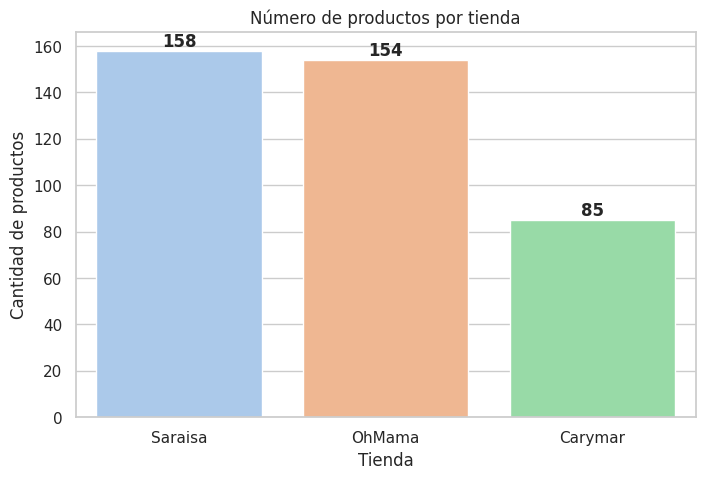

/tmp/ipython-input-3157090679.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=productos_por_categoria.index, y=productos_por_categoria.values, palette="muted")


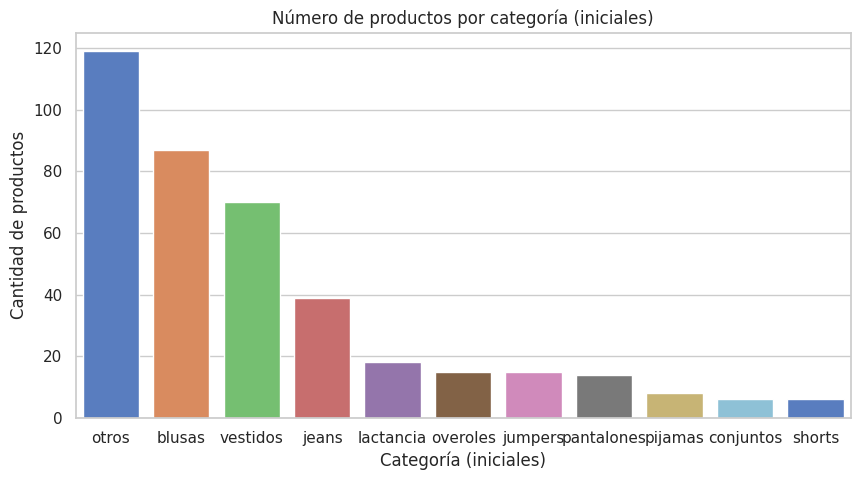

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar dataset
df = pd.read_csv("productos_todas_las_tiendas.csv", encoding="utf-8-sig")

# Función para renombrar categorías según sus iniciales
def categoria_inicial(cat):
    cat = str(cat).lower()
    if cat.startswith("blusa"):
        return "blusas"
    elif cat.startswith("vestido"):
        return "vestidos"
    elif cat.startswith("jean"):
        return "jeans"
    elif cat.startswith("pantalon") or cat.startswith("pantalones"):
        return "pantalones"
    elif cat.startswith("short"):
        return "shorts"
    elif cat.startswith("jumper") or cat.startswith("enterizo"):
        return "jumpers"
    elif cat.startswith("overol"):
        return "overoles"
    elif cat.startswith("conjunto"):
        return "conjuntos"
    elif cat.startswith("pijamas"):
        return "pijamas"
    elif cat.startswith("lactancia"):
        return "lactancia"
    else:
        return "otros"



df["Categoria_ini"] = df["Categoria"].apply(categoria_inicial)


productos_por_tienda = df.groupby("Tienda")["Producto"].count().sort_values(ascending=False)


productos_por_categoria = df.groupby("Categoria_ini")["Producto"].count().sort_values(ascending=False)


sns.set(style="whitegrid")


plt.figure(figsize=(8,5))
sns.barplot(x=productos_por_tienda.index, y=productos_por_tienda.values, palette="pastel")
plt.title("Número de productos por tienda")
plt.ylabel("Cantidad de productos")
plt.xlabel("Tienda")
for i, v in enumerate(productos_por_tienda.values):
    plt.text(i, v + 2, str(v), ha='center', fontweight='bold')
plt.show()


plt.figure(figsize=(10,5))
sns.barplot(x=productos_por_categoria.index, y=productos_por_categoria.values, palette="muted")
plt.title("Número de productos por categoría (iniciales)")
plt.ylabel("Cantidad de productos")
plt.xlabel("Categoría (iniciales)")

plt.show()


In [ ]:

# Apply the categorization function
df["Categoria_ini"] = df["Categoria"].apply(categoria_inicial)

# Filter for the 'otros' category
otros_df = df[df["Categoria_ini"] == "otros"]

# Display the filtered DataFrame
display(otros_df)

,Producto,Categoria,Precio,Colores,Descripcion,URL,Tienda,Tallas,Estampados,Categoria_ini
65,Leggins lycra algodón,frontpage,$50.000,"S, M, L, XL, XXL, Negro, Beige, Chocolate, Azu...",No hay nada mas cómodo que un leggins ! Son ge...,https://www.carymar.co/collections/frontpage/p...,Carymar,NaN,NaN,otros
66,Sudadera materna,frontpage,$72.000,"S, M, L, XL, XXL, Negra, Azul Oscuro, Beige, V...",Esta es una prenda especialmente pensada para ...,https://www.carymar.co/collections/frontpage/p...,Carymar,NaN,NaN,otros
85,Vestido Indira,nueva-coleccion,"$91,800",mostaza,Este vestido combina perfectamente con sandali...,https://saraisa.co/producto/vestido-indira/,Saraisa,xl,NaN,otros
86,Vestido Ailén,nueva-coleccion,"$106,250",beige,Este hermosovestido largo en tela chalises la ...,https://saraisa.co/producto/vestido-ailen/,Saraisa,"s, m, l, xl, xxl",NaN,otros
87,Vestido Cataleya,nueva-coleccion,"$109,650","blanco, caqui",Nuestrovestido largo en seda momaes una prenda...,https://saraisa.co/producto/vestido-cataleya-2/,Saraisa,"s, m, xl, xxl",NaN,otros
...,...,...,...,...,...,...,...,...,...,...
392,Pantalón Materno suave con cintura resortada Ohm,compra-todo,"$120,900.00",Azul oscuro,Pantalón Materno resortado - Moda Materna Colo...,https://www.ohmama.com.co/products/pantalon-ma...,OhMama,"SM (6-8), LXL (10-12)",NaN,otros
393,Jogger de Maternidad Deportivo Ohm,compra-todo,"$92,900.00","Gris claro, Negro, Gris oscuro, Azul oscuro, B...",Pantalones Maternos cómodos y modernos Color: ...,https://www.ohmama.com.co/products/jogger-de-m...,OhMama,Única (ultra stretch 6-10),NaN,otros
394,Jogger de Maternidad Deportivo Ohm,compra-todo,"$92,900.00","Gris claro, Negro, Gris oscuro, Azul oscuro, B...",Pantalones Maternos cómodos y modernos Color: ...,https://www.ohmama.com.co/products/jogger-de-m...,OhMama,Única (ultra stretch 6-10),NaN,otros
395,Jean para Embarazada Bota ancha Elo Ohm,compra-todo,"$169,900.00",Azul medio,Jean Moderno para Embarazadas Material: 79% al...,https://www.ohmama.com.co/products/jean-para-e...,OhMama,"SM (6-8), LXL (10-12)",NaN,otros


###¿Cúales son los rangos de precio por Categoría?

###¿Cúal es la categoría con los precios más altos?

<>:9: SyntaxWarning: invalid escape sequence '\$'
<>:9: SyntaxWarning: invalid escape sequence '\$'
/tmp/ipython-input-3852967022.py:9: SyntaxWarning: invalid escape sequence '\$'
  df['Precio_num'] = df['Precio'].replace({'\$':'', ',':''}, regex=True).astype(float)
/tmp/ipython-input-3852967022.py:47: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=promedios.index, y=promedios.values, palette="magma")


 Promedio de precios por categoría:
Categoria_ini
jeans         118958.230769
otros         115787.705882
pijamas       103900.000000
conjuntos     100800.000000
lactancia      98344.444444
vestidos       82933.828571
overoles       65456.400000
blusas         46053.413793
jumpers        37712.133333
pantalones     30690.071429
shorts         25440.833333
Name: Precio_num, dtype: float64


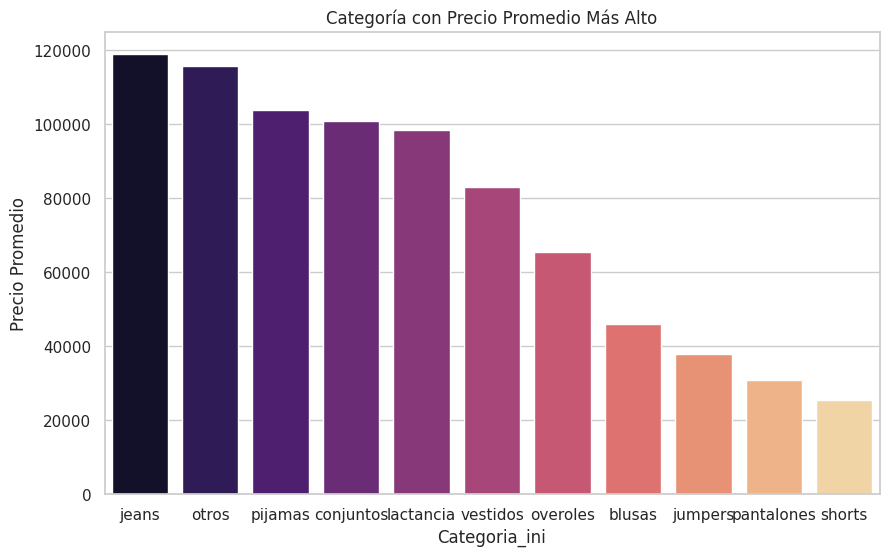

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("productos_todas_las_tiendas.csv", encoding="utf-8-sig")


df['Precio_num'] = df['Precio'].replace({'\$':'', ',':''}, regex=True).astype(float)


def categoria_inicial(cat):
    cat = str(cat).lower()
    if cat.startswith("blusa"):
        return "blusas"
    elif cat.startswith("vestido"):
        return "vestidos"
    elif cat.startswith("jean"):
        return "jeans"
    elif cat.startswith("pantalon") or cat.startswith("pantalones"):
        return "pantalones"
    elif cat.startswith("short"):
        return "shorts"
    elif cat.startswith("jumper") or cat.startswith("enterizo"):
        return "jumpers"
    elif cat.startswith("overol"):
        return "overoles"
    elif cat.startswith("conjunto"):
        return "conjuntos"
    elif cat.startswith("pijamas"):
        return "pijamas"
    elif cat.startswith("lactancia"):
        return "lactancia"
    else:
        return "otros"

df["Categoria_ini"] = df["Categoria"].apply(categoria_inicial)


promedios = df.groupby("Categoria_ini")['Precio_num'].mean().sort_values(ascending=False)

print(" Promedio de precios por categoría:")
print(promedios)


plt.figure(figsize=(10,6))
sns.barplot(x=promedios.index, y=promedios.values, palette="magma")
plt.title("Categoría con Precio Promedio Más Alto")
plt.ylabel("Precio Promedio")
plt.show()


### Conclusión


En conclusión pudimos determinar que las prendas que presentan mayor variación en cuanto a diseño son las blusas, ya que hay 154 tipos de blusas diferentes en todo el dataset y gracias al último gráfico pudimos visualizar la variación de los precios en las diferentes categorías y determinar cuáles son los tipos de prendas más caras y más baratas.

En este momento realizamos el proceso así pero en un futuro pensamos usar procesamiento de lenguaje natural para aplicarlo en la columna "otros" para ver todos los elementos que están dentro de ella y categorizarlos correctamente.


#Mejoras y Limpieza


In [ ]:
df = pd.read_csv("productos_todas_las_tiendas.csv", encoding="utf-8-sig")

print("Filas x columnas:", df.shape)
print(df.dtypes)
print("\nNulos por columna:\n", df.isna().sum())
df.head(3)

Filas x columnas: (397, 9)
Producto       object
Categoria      object
Precio         object
Colores        object
Descripcion    object
URL            object
Tienda         object
Tallas         object
Estampados     object
dtype: object

Nulos por columna:
 Producto         0
Categoria        0
Precio           0
Colores         39
Descripcion      0
URL              0
Tienda           0
Tallas         119
Estampados     386
dtype: int64


,Producto,Categoria,Precio,Colores,Descripcion,URL,Tienda,Tallas,Estampados
0,Camiseta Polo,blusas,$55.000,"S, M, L, XL, Rosa, Blanca, Azul, S / Rosa, S /...","Camiseta tipo polo con bordado de cigüeña, cor...",https://www.carymar.co/collections/blusas/prod...,Carymar,NaN,NaN
1,Blusa Carmela,blusas,$62.000,"S, M, L, XL, Azul, Salmón, Verde, S / Azul, S ...","La blusa Carmela es una prenda super chic, con...",https://www.carymar.co/collections/blusas/prod...,Carymar,NaN,NaN
2,Blusa straple materna,blusas,$59.000,"Blanca, Rosa, Azul, Verde, S, M, L, XL, Blanca...",Blusa straple enresortada adelante y atrás par...,https://www.carymar.co/collections/blusas/prod...,Carymar,NaN,NaN


In [ ]:
import re, numpy as np

def parse_precio(x):
    if pd.isna(x):
        return np.nan
    s = str(x)
    # 1) Elimina símbolo $ y espacios
    s = s.replace("$","").strip()
    # 2) Si tiene coma como separador de miles → quítala
    s = s.replace(",","")
    # 3) Si tiene punto decimal al final → quítalo
    if s.endswith(".00"):
        s = s[:-3]
    # 4) Deja solo dígitos
    s = re.sub(r"[^\d]", "", s)
    return float(s) if s else np.nan


In [ ]:
df["Precio_num"] = df["Precio"].apply(parse_precio)


In [ ]:
import re, unicodedata
import pandas as pd
from collections import Counter

def norm_text(s: str) -> str:
    if pd.isna(s): return s
    s = str(s).lower()
    s = unicodedata.normalize("NFKD", s)
    s = "".join(ch for ch in s if not unicodedata.category(ch).startswith("M"))  # sin tildes
    s = s.replace("+", " ").replace("_", " ").replace("-", " ")
    s = re.sub(r"\s+agotado\b", "", s)  # quita 'agotado'
    s = re.sub(r"\s+", " ", s).strip()
    return s

# separadores primarios en la columna Colores
SEP = r"[\/,;|]"

# stopwords de contexto
STOPWORDS_COLOR = {
    "camiseta","camisa","blusa","pantalon","pantalones","vestido","enterizo",
    "estampado","estampada","estampadas","estampados",
    "flores","rayas","cuadros","puntos","pepas","fondo","entero","tono","clasico","clasica",
    "con","de","y","para","oscuro","claro"
}

# TALLAS
TALLAS = {
    "xxs","xs","s","m","l","xl","xxl","xxxl","2xl","3xl","4xl",
    "talla unica","unica","u","tallaunica"
}

# paleta canónica
PALETA = {
    "negro","blanco","gris",
    "azul","azul claro","azul oscuro",
    "verde","verde oliva","turquesa",
    "rojo","rosa","morado",
    "amarillo","naranja","café","beige","salmón","camel","caqui","multicolor"
}

# sinónimos -> canónico
COLOR_MAP = {
    # blancos / beige
    "blanca":"blanco","blanco hueso":"blanco","hueso":"blanco","offwhite":"blanco",
    "blanco crema":"beige","crema":"beige","cremita":"beige","blanco marfil":"blanco",
    "blanco hueso flores palo rosa":"blanco",
    "arena":"beige","piel":"beige","nude":"beige","caqui":"caqui","camel":"camel",
    # azules y turquesas
    "navy":"azul oscuro","azul marino":"azul oscuro",
    "azul hielo":"azul claro","celeste":"azul claro","azul claro":"azul claro",
    "azul medio":"azul","azul 2":"azul","azul2":"azul","azul-claro":"azul claro",
    "azul-medio":"azul","azul-oscuro":"azul oscuro","azul-oscuro-clasico":"azul oscuro",
    "petroleo":"turquesa","azul petroleo":"turquesa","aguamarina":"turquesa",
    # verdes
    "militar":"verde oliva","verde oliva":"verde oliva",
    # cafés
    "cafe":"café","marron":"café","chocolate":"café","mocca":"café","moca":"café",
    # rojos / rosas / morados / naranjas
    "vinotinto":"rojo","granate":"rojo","burdeos":"rojo","vino":"rojo",
    "rosada":"rosa","rosado":"rosa","palo rosa":"rosa","palo de rosa":"rosa",
    "magenta":"rosa","coral":"naranja","mandarina":"naranja","naranjado":"naranja",
    "berenjena":"morado","mora":"morado","morada":"morado","purpura":"morado","lila":"morado",
    "salmon":"salmón","mostaza":"amarillo",
    # otros
    "plata":"gris","dorado":"amarillo",

    "arcilla": "beige",
    "terracota": "naranja",
    "fucsia": "rosa",
    "negra": "negro",
    "rosados": "rosa",
    "rayas rojas": "rojo",
}


In [ ]:
def join_bigrams(tokens):
    """Reconstruye combinaciones válidas tipo 'azul oscuro', 'azul claro'."""
    out = []
    i = 0
    while i < len(tokens):
        if i+1 < len(tokens) and f"{tokens[i]} {tokens[i+1]}" in PALETA:
            out.append(f"{tokens[i]} {tokens[i+1]}")
            i += 2
        else:
            out.append(tokens[i])
            i += 1
    return out

def classify_token(tok):
    """Devuelve ('color', valor) o ('talla', valor) o (None, None)."""
    t = norm_text(tok)

    # tallas
    if t in TALLAS:
        return ("talla", t)

    # elimina stopwords aisladas
    if t in STOPWORDS_COLOR:
        return (None, None)

    # mapeo directo a color si existe
    t = COLOR_MAP.get(t, t)

    # corta ruido tipo 'cuadros rosados' -> 'rosados' -> 'rosa'
    t = re.sub(r"\b(cuadros|rayas|puntos|pepas|fondo|entero|tono)\b", "", t).strip()
    t = re.sub(r"\s+", " ", t)

    # tokenización fina por espacios
    pieces = [p for p in t.split() if p and p not in STOPWORDS_COLOR]
    pieces = join_bigrams(pieces)  # rearmar bigramas

    colors = []
    for p in pieces:
        p2 = COLOR_MAP.get(p, p)
        if p2 in PALETA:
            colors.append(p2)

    if colors:
        # puede regresar múltiples colores (ej: 'azul oscuro blanco')
        return ("color", colors)

    return (None, None)

def parse_colores_y_tallas(cell):
    """Devuelve (colores_list, tallas_list) a partir de la celda cruda."""
    if pd.isna(cell) or not str(cell).strip():
        return [], []
    s = norm_text(cell)

    # separar por separadores y conectores
    parts = re.split(SEP, s)
    split_more = []
    for p in parts:
        split_more += re.split(r"\by\b|\+", p)  # divide 'azul y blanco'  / 'azul + blanco'
    parts = [p.strip() for p in (parts + split_more) if p.strip()]

    colores, tallas = [], []
    for p in parts:
        kind, val = classify_token(p)
        if kind == "talla":
            if val not in tallas:
                tallas.append(val)
        elif kind == "color":
            for c in val:
                if c not in colores:
                    colores.append(c)

    return colores, tallas

# aplicar
df["colores_list"], df["tallas_list"] = zip(*df["Colores"].apply(parse_colores_y_tallas))


In [ ]:
# ejemplos
display(df[["Colores","colores_list","tallas_list"]].head(12))

# frecuencias
col_freq = Counter([c for L in df["colores_list"] for c in L])
tal_freq = Counter([t for L in df["tallas_list"]  for t in L])
print("Top colores:", col_freq.most_common(15))
print("Top tallas:", tal_freq.most_common(10))

# auditoría de tokens crudos para revisar rezagos
def tokens_crudos(col):
    raw = df[col].dropna().map(norm_text)
    toks = []
    for s in raw:
        toks += [p.strip() for p in re.split(SEP, s) if p.strip()]
    return toks

toks = set(tokens_crudos("Colores"))

# filtramos lo que claramente no debería contarse como 'desconocido'
canonicos = set(PALETA) | set(COLOR_MAP.keys()) | set(COLOR_MAP.values()) | TALLAS | STOPWORDS_COLOR
# pasamos por classify_token: si no devuelve color/talla, lo listamos
desconocidos = sorted([t for t in toks if classify_token(t)[0] is None])

print("Tokens potencialmente desconocidos (muestra 40):", desconocidos[:40])


,Colores,colores_list,tallas_list
0,"S, M, L, XL, Rosa, Blanca, Azul, S / Rosa, S /...","[rosa, blanco, azul]","[s, m, l, xl]"
1,"S, M, L, XL, Azul, Salmón, Verde, S / Azul, S ...","[azul, salmón, verde]","[s, m, l, xl]"
2,"Blanca, Rosa, Azul, Verde, S, M, L, XL, Blanca...","[blanco, rosa, azul, verde]","[s, m, l, xl]"
3,"S, M, L, XL, Blanca, Azul Oscuro, Verde, Rosa,...","[blanco, azul, verde, rosa]","[s, m, l, xl]"
4,"S, M, L, XL, S, M, L, XL",[],"[s, m, l, xl]"
5,"S, M, L, XL, Blanca, S / Blanca, M / Blanca, L...",[blanco],"[s, m, l, xl]"
6,"S, M, L, XL, Azul Oscuro, Blanca, Rosa, S / Az...","[azul, blanco, rosa]","[s, m, l, xl]"
7,"S, M, L, XL, Rosada, Negra, Azul, S / Rosada, ...","[rosa, negro, azul]","[s, m, l, xl]"
8,"S, M, L, XL, Verde Clara, Blanca, Lila, Azul O...","[verde, blanco, morado, azul, rosa]","[s, m, l, xl]"
9,"S, M, L, XL, Blanca, Lila, Rosa, Morado, S / B...","[blanco, morado, rosa]","[s, m, l, xl]"


Top colores: [('negro', 136), ('azul', 134), ('rosa', 105), ('blanco', 105), ('verde', 85), ('beige', 79), ('gris', 61), ('verde oliva', 36), ('café', 34), ('morado', 27), ('naranja', 19), ('camel', 15), ('rojo', 14), ('amarillo', 11), ('caqui', 3)]
Top tallas: [('s', 85), ('m', 84), ('l', 84), ('xl', 84), ('xxl', 17)]
Tokens potencialmente desconocidos (muestra 40): ['tono oscuro']


# PREDICCION CATEGORIA


In [ ]:
print(df["Categoria"].value_counts().sort_index())


Categoria
blusas                         59
blusas-y-camisetas-maternas    28
combos                         14
compra-todo                    32
conjunto                        6
enterizos                       6
frontpage                       2
jeans                           7
jeans-maternos                 32
jumper-y-enterizo               9
lactancia                      18
leggings                        1
nueva-coleccion                32
outlet                         32
overoles                       15
pantalones                     14
pijamas-lactancia               8
ropa-interior-materna           6
shorts                          2
shorts-1                        4
vestidos                       54
vestidos-maternos              16
Name: count, dtype: int64


Nos damos cuenta que hay bastantes temas que revisar en como se esta categorizando

In [ ]:
CAT_MAP = {
    "blusas-y-camisetas-maternas": "blusas",
    "jeans-maternos": "jeans",
    "jumper-y-enterizo": "enterizos",
    "shorts-1": "shorts",
    "vestidos-maternos": "vestidos",
    "pijamas-lactancia": "pijamas",
    "ropa-interior-materna": "ropa-interior",
    # categorías a eliminar (se asigna None)
    "frontpage": None,
    "nueva-coleccion": None,
    "outlet": None,
    "compra-todo": None,
    "combos": None
}

df["Categoria_norm"] = df["Categoria"].replace(CAT_MAP)
# eliminamos filas sin categoría final
df = df.dropna(subset=["Categoria_norm"])


In [ ]:
df["Categoria_norm"] = df["Categoria"].replace(CAT_MAP)
df = df.dropna(subset=["Categoria_norm"]).reset_index(drop=True)

# 3) Verificación
print("\nDistribución tras normalizar:\n", df["Categoria_norm"].value_counts())


Distribución tras normalizar:
 Categoria_norm
blusas           87
vestidos         70
jeans            39
lactancia        18
enterizos        15
overoles         15
pantalones       14
pijamas           8
conjunto          6
shorts            6
ropa-interior     6
leggings          1
Name: count, dtype: int64


Ya con una limpieza continuamos con el proceso

In [ ]:
from sklearn.preprocessing import MultiLabelBinarizer
import pandas as pd # Import pandas
import numpy as np # Import numpy
import re # Import re
import unicodedata # Import unicodedata

# Re-load the dataframe to ensure it's defined and has the latest columns
df = pd.read_csv("productos_todas_las_tiendas.csv", encoding="utf-8-sig")

# Re-apply normalization functions if they are not guaranteed to be run before this cell
def norm_text(s: str) -> str:
    if pd.isna(s): return s
    s = str(s).lower()
    s = unicodedata.normalize("NFKD", s)
    s = "".join(ch for ch in s if not unicodedata.category(ch).startswith("M"))  # sin tildes
    s = s.replace("+", " ").replace("_", " ").replace("-", " ")
    s = re.sub(r"\s+agotado\b", "", s)  # quita 'agotado'
    s = re.sub(r"\s+", " ", s).strip()
    return s

# Define the category mapping again for robustness
def _norm_cat(s):
    if pd.isna(s): return ""
    s = str(s).strip().lower()
    s = unicodedata.normalize("NFKD", s)
    s = "".join(ch for ch in s if not unicodedata.category(ch).startswith("M"))  # sin tildes
    s = s.replace("_","-")
    s = re.sub(r"\s+", "-", s)
    return s

CAT_MAP = {
    "blusas-y-camisetas-maternas": "blusas",
    "jeans-maternos": "jeans",
    "jumper-y-enterizo": "enterizos",
    "shorts-1": "shorts",
    "vestidos-maternos": "vestidos",
    "pijamas-lactancia": "pijamas",
    "ropa-interior-materna": "ropa-interior",
    # navegación/marketing (descartar)
    "frontpage": None, "nueva-coleccion": None, "outlet": None,
    "compra-todo": None, "combos": None,
}

def categoria_inicial(cat_raw):
    cat = _norm_cat(cat_raw)
    if cat in CAT_MAP:
        return CAT_MAP[cat]  # puede ser None
    if cat.startswith("blusa"):         return "blusas"
    if cat.startswith("vestido"):       return "vestidos"
    if cat.startswith("jean"):          return "jeans"
    if cat.startswith("pantalon"):      return "pantalones"
    if cat.startswith("pantalones"):    return "pantalones"
    if cat.startswith("short"):         return "shorts"
    if cat.startswith("enterizo"):      return "enterizos"
    if cat.startswith("overol"):        return "overoles"
    if cat.startswith("conjunto"):      return "conjunto"
    if cat.startswith("pijama"):        return "pijamas"
    if cat.startswith("lactancia"):     return "lactancia"
    if cat.startswith("ropa-interior"): return "ropa-interior"
    if cat.startswith("legging"):       return "leggings"
    return "otros"

df["Categoria_norm"] = df["Categoria"].apply(categoria_inicial)
# elimina filas de navegación/marketing
df = df[df["Categoria_norm"].notna()].reset_index(drop=True)

# Also ensure the 'colores_list' and 'tallas_list' columns exist by re-running the parsing logic
# Assume parse_colores_y_tallas, SEP, TALLAS, PALETA, COLOR_MAP, STOPWORDS_COLOR are defined in previous cells
# For robustness, redefine them here or ensure the cells defining them are run before this cell.
# Given the notebook state, let's assume they are defined and applied correctly in prior cells.
# If you face NameErrors for these, you might need to include their definitions here as well.
# For now, assuming 'colores_list' and 'tallas_list' are already in the dataframe from previous steps.

# Texto
df["texto"] = df["Producto"].fillna("") + " " + df["Descripcion"].fillna("")

# Dummies de colores y tallas
# Ensure the columns exist before trying to access them
colores_list_exists = 'colores_list' in df.columns
tallas_list_exists = 'tallas_list' in df.columns

mlb_col = MultiLabelBinarizer()
mlb_tal = MultiLabelBinarizer()

col_dum = pd.DataFrame() # Initialize as empty
if colores_list_exists:
    # Ensure the list is not empty for fit_transform
    if df['colores_list'].apply(lambda x: len(x) > 0).any():
        col_dum = pd.DataFrame(mlb_col.fit_transform(df["colores_list"]),
                               columns=[f"color_{c}" for c in mlb_col.classes_],
                               index=df.index)

tal_dum = pd.DataFrame() # Initialize as empty
if tallas_list_exists:
     # Ensure the list is not empty for fit_transform
    if df['tallas_list'].apply(lambda x: len(x) > 0).any():
        tal_dum = pd.DataFrame(mlb_tal.fit_transform(df["tallas_list"]),
                               columns=[f"talla_{t}" for t in mlb_tal.classes_],
                               index=df.index)

# Concatenate, handling cases where dummy dataframes might be empty
if not col_dum.empty and not tal_dum.empty:
    df_ml = pd.concat([df, col_dum, tal_dum], axis=1)
elif not col_dum.empty:
    df_ml = pd.concat([df, col_dum], axis=1)
elif not tal_dum.empty:
     df_ml = pd.concat([df, tal_dum], axis=1)
else:
    df_ml = df.copy() # No dummies to concatenate


# Subconjunto con categorías reales (para entrenar) y separar “otros”
mask_real = df_ml["Categoria_norm"] != "otros"
mask_otros = df_ml["Categoria_norm"] == "otros"

# Build X_cols dynamically based on available dummy columns
X_cols = ["texto", "Categoria_norm"]
if not col_dum.empty:
    X_cols.extend(list(col_dum.columns))
if not tal_dum.empty:
    X_cols.extend(list(tal_dum.columns))

# Filter X_all and y_all based on available columns in df_ml
X_all = df_ml[X_cols]
y_all = df_ml["Categoria_norm"]

In [ ]:
print("Tamaño total:", X_all.shape)
print("Clases (incluye otros):\n", y_all.value_counts())


Tamaño total: (285, 2)
Clases (incluye otros):
 Categoria_norm
blusas           87
vestidos         70
jeans            39
lactancia        18
enterizos        15
overoles         15
pantalones       14
pijamas           8
conjunto          6
shorts            6
ropa-interior     6
leggings          1
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split

MIN_PER_CLASS = 3
counts = y_all[mask_real].value_counts()
rare = counts[counts < MIN_PER_CLASS].index.tolist()
print("Clases raras (<3):", rare)

mask_trainable = mask_real & (~y_all.isin(rare))
X = X_all[mask_trainable]
y = y_all[mask_trainable]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify=y, test_size=0.2, random_state=42
)

print("Train dist:\n", y_train.value_counts(), "\n\nTest dist:\n", y_test.value_counts())


Clases raras (<3): ['leggings']
Train dist:
 Categoria_norm
blusas           70
vestidos         56
jeans            31
lactancia        14
overoles         12
enterizos        12
pantalones       11
pijamas           6
ropa-interior     5
shorts            5
conjunto          5
Name: count, dtype: int64 

Test dist:
 Categoria_norm
blusas           17
vestidos         14
jeans             8
lactancia         4
overoles          3
enterizos         3
pantalones        3
pijamas           2
shorts            1
conjunto          1
ropa-interior     1
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression

# Usamos SOLO texto (mejor para categoría)
X_text = df_ml.loc[mask_trainable, "texto"]
y_text = y  # tus etiquetas filtradas (sin clases < MIN_PER_CLASS)

X_train, X_test, y_train, y_test = train_test_split(
    X_text, y_text, stratify=y_text, test_size=0.10, random_state=42
)

pipe_lr = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=8000, ngram_range=(1,2))),
    ("clf", LogisticRegression(max_iter=4000, class_weight="balanced", n_jobs=-1))
])

# CV estratificada (5 folds)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_macro_f1 = cross_val_score(pipe_lr, X_train, y_train, cv=cv, scoring="f1_macro")
print("CV f1_macro (media±std):", cv_macro_f1.mean(), cv_macro_f1.std())

# Entrenamos con todo el train y evaluamos en test
pipe_lr.fit(X_train, y_train)
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
y_pred = pipe_lr.predict(X_test)
print(classification_report(y_test, y_pred))


CV f1_macro (media±std): 0.6060837445382901 0.0779043038212606
               precision    recall  f1-score   support

       blusas       1.00      0.89      0.94         9
     conjunto       0.00      0.00      0.00         1
    enterizos       0.00      0.00      0.00         1
        jeans       1.00      0.75      0.86         4
    lactancia       0.50      0.50      0.50         2
     overoles       0.00      0.00      0.00         1
   pantalones       0.50      1.00      0.67         1
      pijamas       0.50      1.00      0.67         1
ropa-interior       1.00      1.00      1.00         1
       shorts       0.00      0.00      0.00         1
     vestidos       0.88      1.00      0.93         7

     accuracy                           0.76        29
    macro avg       0.49      0.56      0.51        29
 weighted avg       0.76      0.76      0.75        29



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import unicodedata, re

def _norm_cat(s):
    if pd.isna(s): return ""
    s = str(s).strip().lower()
    s = unicodedata.normalize("NFKD", s)
    s = "".join(ch for ch in s if not unicodedata.category(ch).startswith("M"))  # sin tildes
    s = s.replace("_","-")
    s = re.sub(r"\s+", "-", s)
    return s

CAT_MAP = {
    "blusas-y-camisetas-maternas": "blusas",
    "jeans-maternos": "jeans",
    "jumper-y-enterizo": "enterizos",
    "shorts-1": "shorts",
    "vestidos-maternos": "vestidos",
    "pijamas-lactancia": "pijamas",
    "ropa-interior-materna": "ropa-interior",
    # navegación/marketing (descartar)
    "frontpage": None, "nueva-coleccion": None, "outlet": None,
    "compra-todo": None, "combos": None,
}

def categoria_inicial(cat_raw):
    cat = _norm_cat(cat_raw)
    if cat in CAT_MAP:
        return CAT_MAP[cat]  # puede ser None
    if cat.startswith("blusa"):         return "blusas"
    if cat.startswith("vestido"):       return "vestidos"
    if cat.startswith("jean"):          return "jeans"
    if cat.startswith("pantalon"):      return "pantalones"
    if cat.startswith("pantalones"):    return "pantalones"
    if cat.startswith("short"):         return "shorts"
    if cat.startswith("enterizo"):      return "enterizos"
    if cat.startswith("overol"):        return "overoles"
    if cat.startswith("conjunto"):      return "conjunto"
    if cat.startswith("pijama"):        return "pijamas"
    if cat.startswith("lactancia"):     return "lactancia"
    if cat.startswith("ropa-interior"): return "ropa-interior"
    if cat.startswith("legging"):       return "leggings"
    return "otros"

df["Categoria_ini"] = df["Categoria"].apply(categoria_inicial)
# elimina filas de navegación/marketing
df = df[df["Categoria_ini"].notna()].reset_index(drop=True)


In [ ]:
print(df["Categoria"].value_counts().head(12))
print("\nNormalizadas:\n", df["Categoria_ini"].value_counts())


Categoria
blusas                         59
vestidos                       54
jeans-maternos                 32
blusas-y-camisetas-maternas    28
lactancia                      18
vestidos-maternos              16
overoles                       15
pantalones                     14
jumper-y-enterizo               9
pijamas-lactancia               8
jeans                           7
conjunto                        6
Name: count, dtype: int64

Normalizadas:
 Categoria_ini
blusas           87
vestidos         70
jeans            39
lactancia        18
enterizos        15
overoles         15
pantalones       14
pijamas           8
conjunto          6
shorts            6
ropa-interior     6
leggings          1
Name: count, dtype: int64


Promedio de precios por categoría:
Categoria_ini
jeans            132560.000000
ropa-interior    116900.000000
vestidos         108165.714286
pijamas          103900.000000
conjunto         100800.000000
lactancia         98344.444444
overoles          97824.000000
enterizos         92457.333333
pantalones        80711.428571
shorts            66233.333333
blusas            64161.724138
leggings          55000.000000
Name: Precio_num, dtype: float64


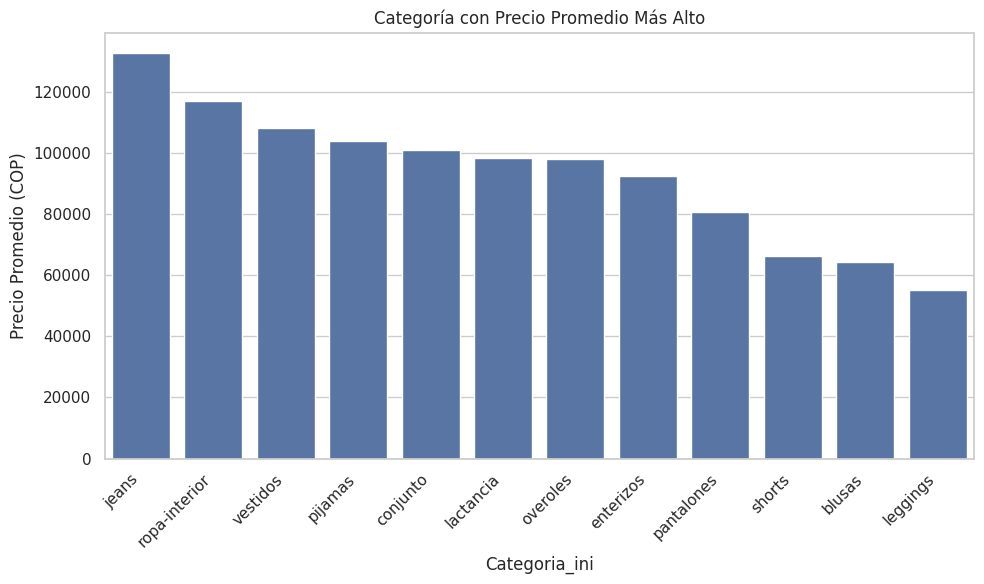

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, numpy as np
import unicodedata

# Define the parse_precio function
def parse_precio(x):
    if pd.isna(x):
        return np.nan
    s = str(x)
    # 1) Elimina símbolo $ y espacios
    s = s.replace("$","").strip()
    # 2) Si tiene coma como separador de miles → quítala
    s = s.replace(",","")
    # 3) Si tiene punto decimal al final → quítalo
    if s.endswith(".00"):
        s = s[:-3]
    # 4) Deja solo dígitos
    s = re.sub(r"[^\d]", "", s)
    return float(s) if s else np.nan

# Define the category normalization function
def _norm_cat(s):
    if pd.isna(s): return ""
    s = str(s).strip().lower()
    s = unicodedata.normalize("NFKD", s)
    s = "".join(ch for ch in s if not unicodedata.category(ch).startswith("M"))  # sin tildes
    s = s.replace("_","-")
    s = re.sub(r"\s+", "-", s)
    return s

CAT_MAP = {
    "blusas-y-camisetas-maternas": "blusas",
    "jeans-maternos": "jeans",
    "jumper-y-enterizo": "enterizos",
    "shorts-1": "shorts",
    "vestidos-maternos": "vestidos",
    "pijamas-lactancia": "pijamas",
    "ropa-interior-materna": "ropa-interior",
    # navegación/marketing (descartar)
    "frontpage": None, "nueva-coleccion": None, "outlet": None,
    "compra-todo": None, "combos": None,
}

def categoria_inicial(cat_raw):
    cat = _norm_cat(cat_raw)
    if cat in CAT_MAP:
        return CAT_MAP[cat]  # puede ser None
    if cat.startswith("blusa"):         return "blusas"
    if cat.startswith("vestido"):       return "vestidos"
    if cat.startswith("jean"):          return "jeans"
    if cat.startswith("pantalon"):      return "pantalones"
    if cat.startswith("pantalones"):    return "pantalones"
    if cat.startswith("short"):         return "shorts"
    if cat.startswith("enterizo"):      return "enterizos"
    if cat.startswith("overol"):        return "overoles"
    if cat.startswith("conjunto"):      return "conjunto"
    if cat.startswith("pijama"):        return "pijamas"
    if cat.startswith("lactancia"):     return "lactancia"
    if cat.startswith("ropa-interior"): return "ropa-interior"
    if cat.startswith("legging"):       return "leggings"
    return "otros"


# Load the dataset again to ensure 'Precio' column is available
df = pd.read_csv("productos_todas_las_tiendas.csv", encoding="utf-8-sig")

# Calculate the Precio_num column
df["Precio_num"] = df["Precio"].apply(parse_precio)

# Create the Categoria_ini column
df["Categoria_ini"] = df["Categoria"].apply(categoria_inicial)


promedios = (
    df.groupby("Categoria_ini")["Precio_num"]
      .mean()
      .sort_values(ascending=False)
)

print("Promedio de precios por categoría:")
print(promedios)

plt.figure(figsize=(10,6))
sns.barplot(x=promedios.index, y=promedios.values)
plt.title("Categoría con Precio Promedio Más Alto")
plt.ylabel("Precio Promedio (COP)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
from pathlib import Path
import unicodedata, re

# Define the category normalization function (assuming it's not defined elsewhere in the visible cells)
def _norm_cat(s):
    if pd.isna(s): return ""
    s = str(s).strip().lower()
    s = unicodedata.normalize("NFKD", s)
    s = "".join(ch for ch in s if not unicodedata.category(ch).startswith("M"))  # sin tildes
    s = s.replace("_","-")
    s = re.sub(r"\s+", "-", s)
    return s

CAT_MAP = {
    "blusas-y-camisetas-maternas": "blusas",
    "jeans-maternos": "jeans",
    "jumper-y-enterizo": "enterizos",
    "shorts-1": "shorts",
    "vestidos-maternos": "vestidos",
    "pijamas-lactancia": "pijamas",
    "ropa-interior-materna": "ropa-interior",
    # navegación/marketing (descartar)
    "frontpage": None, "nueva-coleccion": None, "outlet": None,
    "compra-todo": None, "combos": None,
}

def categoria_inicial(cat_raw):
    cat = _norm_cat(cat_raw)
    if cat in CAT_MAP:
        return CAT_MAP[cat]  # puede ser None
    if cat.startswith("blusa"):         return "blusas"
    if cat.startswith("vestido"):       return "vestidos"
    if cat.startswith("jean"):          return "jeans"
    if cat.startswith("pantalon"):      return "pantalones"
    if cat.startswith("pantalones"):    return "pantalones"
    if cat.startswith("short"):         return "shorts"
    if cat.startswith("enterizo"):      return "enterizos"
    if cat.startswith("overol"):        return "overoles"
    if cat.startswith("conjunto"):      return "conjunto"
    if cat.startswith("pijama"):        return "pijamas"
    if cat.startswith("lactancia"):     return "lactancia"
    if cat.startswith("ropa-interior"): return "ropa-interior"
    if cat.startswith("legging"):       return "leggings"
    return "otros"


# Load the dataset again to ensure 'Precio' column is available
df = pd.read_csv("productos_todas_las_tiendas.csv", encoding="utf-8-sig")

# Calculate the Precio_num column (Assuming parse_precio is defined in a previous cell)
# If not, you might need to include its definition here as well.
# For robustness, let's include it.
def parse_precio(x):
    if pd.isna(x):
        return np.nan
    s = str(x)
    # 1) Elimina símbolo $ y espacios
    s = s.replace("$","").strip()
    # 2) Si tiene coma como separador de miles → quítala
    s = s.replace(",","")
    # 3) Si tiene punto decimal al final → quítalo
    if s.endswith(".00"):
        s = s[:-3]
    # 4) Deja solo dígitos
    s = re.sub(r"[^\d]", "", s)
    return float(s) if s else np.nan

df["Precio_num"] = df["Precio"].apply(parse_precio)

# Create the Categoria_norm column
df["Categoria_norm"] = df["Categoria"].apply(categoria_inicial)


print("Shape:", df.shape)
print("\nTipos de datos:\n", df.dtypes)
print("\nNulos:\n", df.isna().sum())

# Precios
print("\nEstadísticas Precio_num:\n", df["Precio_num"].describe())
print("Ejemplos sospechosos (<1000 COP):")
print(df.loc[df["Precio_num"] < 1000, ["Producto","Precio","Precio_num"]].head(5))

# Categorías
print("\nCategorias únicas:\n", sorted(df["Categoria_norm"].dropna().unique()))
print(df["Categoria_norm"].value_counts())

# Colores y tallas
from collections import Counter
# Ensure colores_list and tallas_list are created before accessing them
# Assuming the parsing functions (parse_colores_y_tallas, norm_text, join_bigrams, classify_token, etc.)
# and necessary constants (SEP, TALLAS, PALETA, COLOR_MAP, STOPWORDS_COLOR)
# are defined and applied in previous cells that have already been executed.
# If not, you might need to include their definitions and application here.
# For robustness, let's assume they are needed and add the code to create them.

# Assuming the necessary helper functions are defined and applied in previous cells.
# If not, uncomment and include the code from the previous relevant cells here.
# from collections import Counter
# import re, unicodedata
# from sklearn.preprocessing import MultiLabelBinarizer
#
# # Define helper functions and constants here if they are not guaranteed to be run before this cell.
# # For instance, norm_text, parse_colores_y_tallas, classify_token, SEP, TALLAS, PALETA, COLOR_MAP, STOPWORDS_COLOR
#
# # Apply the parsing to create colores_list and tallas_list
# df["colores_list"], df["tallas_list"] = zip(*df["Colores"].apply(parse_colores_y_tallas))


if "colores_list" in df.columns:
    col_freq = Counter([c for L in df["colores_list"] for c in L])
    print("\nTop colores:", col_freq.most_common(10))
if "tallas_list" in df.columns:
    tal_freq = Counter([t for L in df["tallas_list"] for t in L])
    print("Top tallas:", tal_freq.most_common(10))

Shape: (397, 11)

Tipos de datos:
 Producto           object
Categoria          object
Precio             object
Colores            object
Descripcion        object
URL                object
Tienda             object
Tallas             object
Estampados         object
Precio_num        float64
Categoria_norm     object
dtype: object

Nulos:
 Producto            0
Categoria           0
Precio              0
Colores            39
Descripcion         0
URL                 0
Tienda              0
Tallas            119
Estampados        386
Precio_num          0
Categoria_norm    112
dtype: int64

Estadísticas Precio_num:
 count       397.000000
mean     100281.876574
std       42782.015294
min       36400.000000
25%       72000.000000
50%       90000.000000
75%      119900.000000
max      287820.000000
Name: Precio_num, dtype: float64
Ejemplos sospechosos (<1000 COP):
Empty DataFrame
Columns: [Producto, Precio, Precio_num]
Index: []

Categorias únicas:
 ['blusas', 'conjunto', 'enterizos', 

count       397.000000
mean     100281.876574
std       42782.015294
min       36400.000000
25%       72000.000000
50%       90000.000000
75%      119900.000000
max      287820.000000
Name: Precio_num, dtype: float64


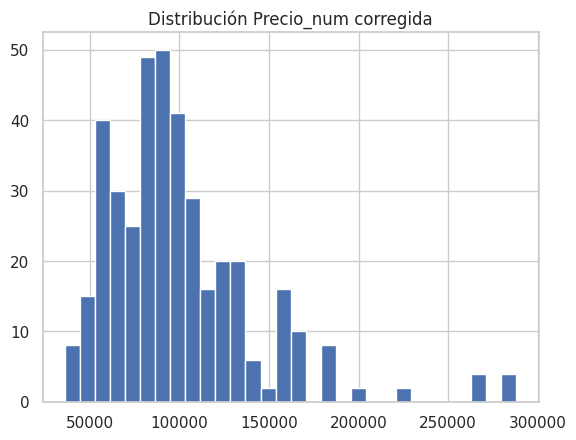

In [ ]:
print(df["Precio_num"].describe())
plt.hist(df["Precio_num"], bins=30)
plt.title("Distribución Precio_num corregida")
plt.show()


Tienda                                                    Producto      Precio  Precio_num Categoria_norm
OhMama                 Pack 2 Pantalones de Maternidad Oficina Ohm $287,820.00    287820.0          jeans
OhMama                 Pack 2 Pantalones de Maternidad Oficina Ohm $287,820.00    287820.0          jeans
OhMama                 Pack 2 Pantalones de Maternidad Oficina Ohm $287,820.00    287820.0           None
OhMama                 Pack 2 Pantalones de Maternidad Oficina Ohm $287,820.00    287820.0           None
OhMama Pack Jean para Embarazadas Emma gris + Leggings Premium Ohm $266,220.00    266220.0           None
OhMama Pack Jean para Embarazadas Emma gris + Leggings Premium Ohm $266,220.00    266220.0           None
OhMama    Pack Jean de Embarazo Julia negro + Leggings Premium Ohm $266,220.00    266220.0           None
OhMama    Pack Jean de Embarazo Julia negro + Leggings Premium Ohm $266,220.00    266220.0           None
OhMama                                 Pack 2 

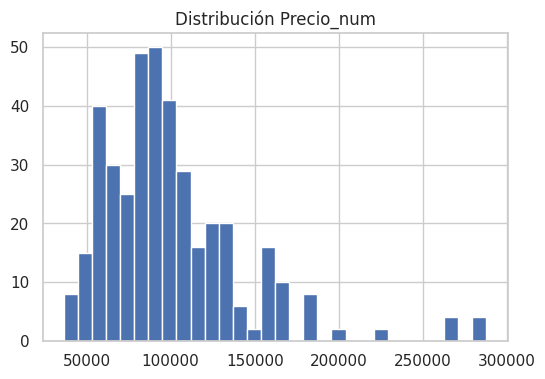

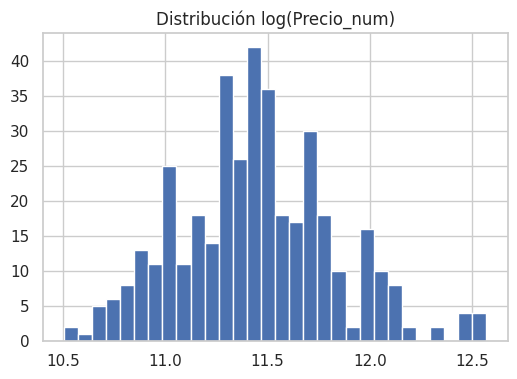

In [ ]:
# Top 10 precios (para detectar outliers)
top_prices = df.sort_values("Precio_num", ascending=False).head(10)
print(top_prices[["Tienda","Producto","Precio","Precio_num","Categoria_norm"]].to_string(index=False))

# Histograma/log-hist (si quieres visualizar)
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.hist(df["Precio_num"], bins=30)
plt.title("Distribución Precio_num")
plt.show()

plt.figure(figsize=(6,4))
import numpy as np
plt.hist(np.log1p(df["Precio_num"]), bins=30)
plt.title("Distribución log(Precio_num)")
plt.show()


In [ ]:
# This cell is no longer needed as the metrics calculation is moved to the previous cell.

In [ ]:
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer, mean_absolute_error
import numpy as np

# 1) Dataset
df_ml = df.copy()
dummy_cols = [c for c in df_ml.columns if c.startswith("color_") or c.startswith("talla_")]

reg_df = df_ml.dropna(subset=["Precio_num","Categoria_norm"]).copy()
reg_df = reg_df[reg_df["Precio_num"] > 0]  # por seguridad

# Create the 'texto' column if it doesn't exist
if "texto" not in reg_df.columns:
    reg_df["texto"] = reg_df["Producto"].fillna("") + " " + reg_df["Descripcion"].fillna("")


X = reg_df[["texto","Categoria_norm"] + dummy_cols]
y = reg_df["Precio_num"].astype(float)

# 2) Preprocesamiento
transfs = [
    ("tfidf", TfidfVectorizer(max_features=8000, ngram_range=(1,2)), "texto"),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["Categoria_norm"]),
]
if dummy_cols:
    transfs.append(("dummies", "passthrough", dummy_cols))

pre = ColumnTransformer(transfs, remainder="drop", verbose_feature_names_out=False)

# 3) Modelo base
base_reg = RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1)

# 4) Envolver en TransformedTargetRegressor (log-transform)
log_reg = TransformedTargetRegressor(
    regressor=Pipeline([("pre", pre), ("model", base_reg)]),
    func=np.log1p,     # y' = log(1+y)
    inverse_func=np.expm1  # y = exp(y') - 1
)

# 5) Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

log_reg.fit(X_train, y_train)
pred = log_reg.predict(X_test)

# 6) Métricas
mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(((pred - y_test.values)**2).mean())
from sklearn.metrics import r2_score
r2 = r2_score(y_test, pred)

print(f"MAE : {mae:,.0f}")
print(f"RMSE: {rmse:,.0f}")
print(f"R²  : {r2: .3f}")

# 7) Validación cruzada (MAE) para mayor confianza
cv = KFold(n_splits=5, shuffle=True, random_state=42)
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
cv_mae = cross_val_score(log_reg, X, y, cv=cv, scoring=mae_scorer)
print(f"CV MAE (media±std): {(-cv_mae).mean():,.0f} ± {(-cv_mae).std():,.0f}")

MAE : 6,480
RMSE: 9,113
R²  :  0.892
CV MAE (media±std): 8,257 ± 1,629


In [ ]:
import pandas as pd
from pathlib import Path

# Guardar
Path("salidas").mkdir(exist_ok=True)
df.to_csv("salidas/productos_clean.csv", index=False, encoding="utf-8-sig")
df_ml.to_csv("salidas/productos_ml.csv", index=False, encoding="utf-8-sig")

# Releer y verificar
df_chk = pd.read_csv("salidas/productos_clean.csv", encoding="utf-8-sig")
dfml_chk = pd.read_csv("salidas/productos_ml.csv", encoding="utf-8-sig")

print("Clean guardado OK:", df_chk.shape == df.shape)
print("ML guardado OK   :", dfml_chk.shape == df_ml.shape)

# Extras útiles
print("Columnas ML (muestra):", [c for c in df_ml.columns[:10]])
print("¿Hay duplicadas ML?:", pd.Index(df_ml.columns).duplicated().any())


Clean guardado OK: True
ML guardado OK   : True
Columnas ML (muestra): ['Producto', 'Categoria', 'Precio', 'Colores', 'Descripcion', 'URL', 'Tienda', 'Tallas', 'Estampados', 'Precio_num']
¿Hay duplicadas ML?: False


Estadísticas Precio_num (corregido):
count       397.000000
mean     100281.876574
std       42782.015294
min       36400.000000
25%       72000.000000
50%       90000.000000
75%      119900.000000
max      287820.000000
Name: Precio_num, dtype: float64


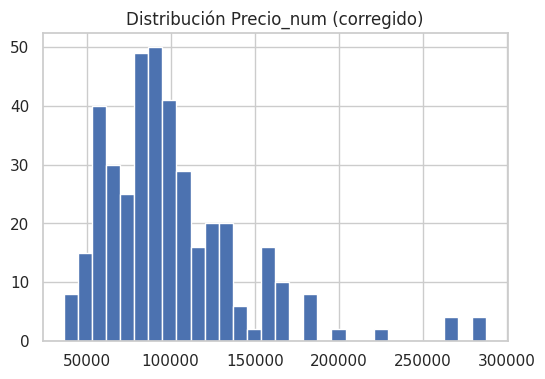

Shapes -> X: (285, 2) | y: (285,) | dummies: 0

[Métricas Test]  MAE: 6,480 | RMSE: 9,113 | R²:  0.892
CV MAE (media±std): 8,257 ± 1,629

=== Predicción de precio por categoría ===
                 n  real_mediana  real_promedio  pred_mediana  pred_promedio  \
Categoria_norm                                                                 
ropa-interior    6       130,900        116,900       130,851        114,073   
jeans           39       119,900        132,560       119,228        130,763   
vestidos        70       107,100        108,166       109,265        106,648   
pijamas          8       104,900        103,900       104,820        103,817   
conjunto         6       101,600        100,800       100,840         99,842   
overoles        15        98,000         97,824        94,892         96,655   
lactancia       18        89,900         98,344        92,823         98,943   
enterizos       15        90,000         92,457        89,845         91,337   
pantalones      14 

In [ ]:

import re, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.preprocessing import OneHotEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, make_scorer


def parse_precio(x):
    if pd.isna(x): return np.nan
    s = str(x).replace("$","").strip()
    s = s.replace(",", "")         # quita miles
    if s.endswith(".00"):          # ignora decimales
        s = s[:-3]
    s = re.sub(r"[^\d]", "", s)    # deja solo dígitos
    return float(s) if s else np.nan

# asegura columna base
assert "Precio" in df.columns, "Falta columna 'Precio' en df."
df["Precio_num"] = df["Precio"].apply(parse_precio)

# Verificación rápida
print("Estadísticas Precio_num (corregido):")
print(df["Precio_num"].describe())
plt.figure(figsize=(6,4)); plt.hist(df["Precio_num"], bins=30); plt.title("Distribución Precio_num (corregido)"); plt.show()


# Texto base
if "texto" not in df.columns:
    df["texto"] = df.get("Producto","").fillna("") + " " + df.get("Descripcion","").fillna("")

# Categoría canónica
cat_col = "Categoria_norm" if "Categoria_norm" in df.columns else "Categoria_ini"
assert cat_col in df.columns, "Falta Categoria_norm/Categoria_ini en df."

# Dummies de colores/tallas si existen (si no, seguimos sin ellas)
dummy_cols = [c for c in df.columns if c.startswith("color_") or c.startswith("talla_")]

# Dataset de regresión
reg_df = df.dropna(subset=["Precio_num", cat_col]).copy()
reg_df = reg_df[reg_df["Precio_num"] > 0]

X = reg_df[["texto", cat_col] + dummy_cols]
y = reg_df["Precio_num"].astype(float)

print("Shapes -> X:", X.shape, "| y:", y.shape, "| dummies:", len(dummy_cols))


transfs = [
    ("tfidf", TfidfVectorizer(max_features=8000, ngram_range=(1,2)), "texto"),
    ("cat",  OneHotEncoder(handle_unknown="ignore", sparse_output=False), [cat_col]),
]
if dummy_cols:
    transfs.append(("dums", "passthrough", dummy_cols))

pre = ColumnTransformer(transfs, remainder="drop", verbose_feature_names_out=False)
base_reg = RandomForestRegressor(n_estimators=400, random_state=42, n_jobs=-1)

model = TransformedTargetRegressor(
    regressor=Pipeline([("pre", pre), ("rf", base_reg)]),
    func=np.log1p, inverse_func=np.expm1
)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

model.fit(X_train, y_train)
pred = model.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2   = r2_score(y_test, pred)
print(f"\n[Métricas Test]  MAE: {mae:,.0f} | RMSE: {rmse:,.0f} | R²: {r2: .3f}")

# CV (MAE) para estabilidad
cv = KFold(n_splits=5, shuffle=True, random_state=42)
mae_scorer = make_scorer(mean_absolute_error, greater_is_better=False)
cv_mae = cross_val_score(model, X, y, cv=cv, scoring=mae_scorer)
print(f"CV MAE (media±std): {(-cv_mae).mean():,.0f} ± {(-cv_mae).std():,.0f}")


# (A) predice todo el dataset disponible
model_full = model.fit(X, y)
df["Precio_pred"] = np.nan
df.loc[reg_df.index, "Precio_pred"] = model_full.predict(X)

# (B) resumen por categoría: real vs predicho
resumen_cat = (
    df.loc[reg_df.index, [cat_col, "Precio_num", "Precio_pred"]]
      .groupby(cat_col)
      .agg(
          n=("Precio_num","size"),
          real_mediana=("Precio_num","median"),
          real_promedio=("Precio_num","mean"),
          pred_mediana=("Precio_pred","median"),
          pred_promedio=("Precio_pred","mean"),
      )
      .sort_values("pred_mediana", ascending=False)
)

resumen_cat["delta_mediana"] = resumen_cat["pred_mediana"] - resumen_cat["real_mediana"]
resumen_cat["delta_%"] = 100 * resumen_cat["delta_mediana"] / resumen_cat["real_mediana"]

print("\n=== Predicción de precio por categoría ===")
pd.set_option("display.float_format", lambda x: f"{x:,.0f}")
print(resumen_cat)


Path("salidas").mkdir(exist_ok=True)
df.to_csv("salidas/productos_clean_con_pred.csv", index=False, encoding="utf-8-sig")
resumen_cat.to_csv("salidas/predicciones_por_categoria.csv", encoding="utf-8-sig")

# relectura para validar
df_chk = pd.read_csv("salidas/productos_clean_con_pred.csv", encoding="utf-8-sig")
res_chk = pd.read_csv("salidas/predicciones_por_categoria.csv", encoding="utf-8-sig")
print("\nGuardado OK:", df_chk.shape == df.shape, "|", res_chk.shape == resumen_cat.shape)


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=pred)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--", lw=2)  # línea ideal
plt.xlabel("Precio real")
plt.ylabel("Precio predicho")
plt.title("Validación: Real vs Predicho")
plt.show()


In [ ]:
res_err = X_test.copy()
res_err["real"] = y_test.values
res_err["pred"] = pred
res_err["abs_err"] = (res_err["real"] - res_err["pred"]).abs()

plt.figure(figsize=(8,4))
sns.boxplot(data=res_err, x="Categoria_norm", y="abs_err")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Error absoluto")
plt.title("Distribución del error por categoría")
plt.show()
